In [1]:
import torch
import matplotlib.pyplot as plt
import h5py
import numpy as np
import galsim
from dataset import SuperResolutionDataset
from model import SuperResolutionDiffusion, SuperResDiffusionUNet, Upsampler
from torch.utils.data import DataLoader


In [47]:
MODEL_PATH = "good_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Load dataset ----
test_dataset = SuperResolutionDataset(
    "../data/Nisp_train_cosmos.hdf5",
    "../data/Nircam_train_cosmos.hdf5",
    split="test",
    sample_fraction=1.0  # use full test set for evaluation
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)


# ---- Load model ----
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1, hidden_dim=64)
upsampler = Upsampler(in_channels=1, out_channels=1, upscale_factor=2)
model = SuperResolutionDiffusion(unet, upsampler).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

SuperResolutionDiffusion(
  (upsampler): Upsampler(
    (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pixel_shuffle): PixelShuffle(upscale_factor=2)
    (relu): ReLU()
    (conv2): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (diffusion): DiffusionModel(
    (unet): SuperResDiffusionUNet(
      (encoder1): Sequential(
        (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
      )
      (encoder2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
      )
      (encoder3): Sequential(
        (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): ReLU()
      )
      (condition_proj): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_mlp): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
      )
      (cross_attention): C

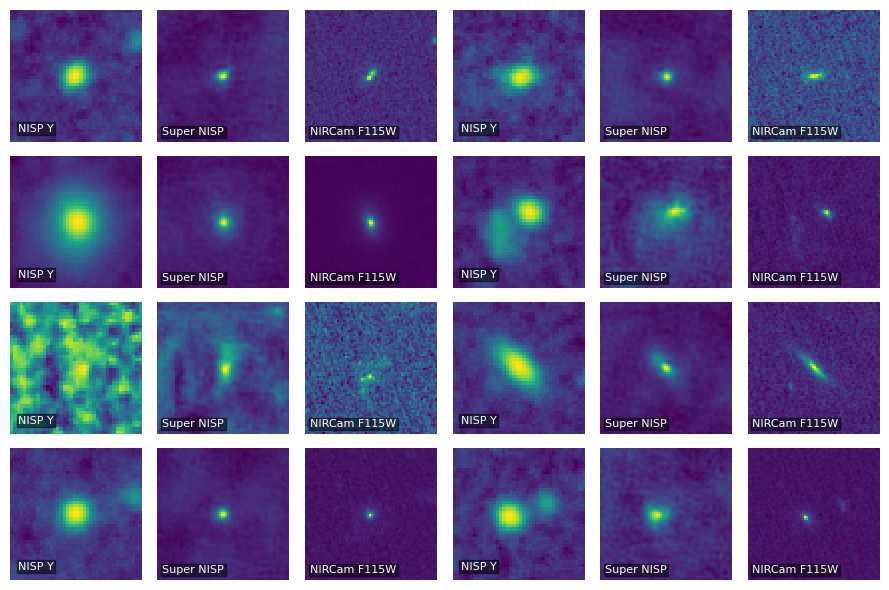

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Parameters
num_examples = 8
t_value = 500
rows, cols = 4, 2  # for subplot grid
fig, axs = plt.subplots(rows, cols * 3, figsize=(9, 6))

for i in range(num_examples):
    # Get random sample
    idx = np.random.randint(0, len(test_dataset))
    lr_img, hr_img = test_dataset[idx]
    lr_img_tensor = lr_img.unsqueeze(0).to("cuda")
    
    t_test = torch.full((lr_img_tensor.shape[0],), t_value, dtype=torch.long, device="cuda")

    # Run model
    with torch.no_grad():
        sr_img = model(lr_img_tensor, t_test).detach().cpu().squeeze(0)

    # Get row and base column index
    row = i // cols
    base_col = (i % cols) * 3

    # Plot NISP Y
    axs[row, base_col].imshow(lr_img[0].cpu().numpy(), origin='lower')
    axs[row, base_col].axis('off')
    axs[row, base_col].text(2, 2, "NISP Y", color='white', fontsize=8, ha='left', va='bottom', bbox=dict(facecolor='black', alpha=0.5, pad=1))

    # Plot Super NISP
    axs[row, base_col + 1].imshow(sr_img[0].numpy(), origin='lower')
    axs[row, base_col + 1].axis('off')
    axs[row, base_col + 1].text(2, 2, "Super NISP", color='white', fontsize=8, ha='left', va='bottom', bbox=dict(facecolor='black', alpha=0.5, pad=1))

    # Plot NIRCam F115W
    axs[row, base_col + 2].imshow(hr_img[0].cpu().numpy(), origin='lower')
    axs[row, base_col + 2].axis('off')
    axs[row, base_col + 2].text(2, 2, "NIRCam F115W", color='white', fontsize=8, ha='left', va='bottom', bbox=dict(facecolor='black', alpha=0.5, pad=1))

plt.tight_layout()
#plt.savefig('supernisp.png')

In [50]:
print(np.shape(lr_img[0]))
print(np.shape(hr_img[0]))
print(len(test_dataset))

torch.Size([40, 40])
torch.Size([66, 66])
12135


In [51]:
# Initialize arrays to store moments
e1_lr, e2_lr, g1_lr, g2_lr = [], [], [], []
e1_hr, e2_hr, g1_hr, g2_hr = [], [], [], []
e1_sr, e2_sr, g1_sr, g2_sr = [], [], [], []


def get_moments(image_np, pixel_scale=0.1):  
    try:
        img = galsim.ImageF(image_np.shape[0], image_np.shape[1], scale=pixel_scale)
        img.array = image_np
        res = galsim.hsm.FindAdaptiveMom(img)
        return [res.observed_e1, res.observed_e2, res.observed_shape.g1, res.observed_shape.g2]
    except Exception as e:
        return [np.nan] * 4


# Loop over dataset
for i in range(2000):#len(test_dataset)):
    lr_img, hr_img = test_dataset[i]
    lr_img_tensor = lr_img.unsqueeze(0).to(DEVICE)
    t_value = 500  # You can try 0, 50, 100, 250, etc.
    t = torch.full((lr_img.shape[0],), t_value, dtype=torch.long, device=DEVICE)

    #t = torch.zeros((1,), dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        sr_img = model(lr_img_tensor, t).detach().cpu().squeeze(0)  # shape (1, H, W)

    # Convert all to numpy
    lr_vals = get_moments(lr_img[0].cpu().numpy(), pixel_scale=0.1)
    hr_vals = get_moments(hr_img[0].cpu().numpy(), pixel_scale=0.06)
    sr_vals = get_moments(sr_img[0].numpy(), pixel_scale=0.06)

    e1_lr.append(lr_vals[0]); e2_lr.append(lr_vals[1]); g1_lr.append(lr_vals[2]); g2_lr.append(lr_vals[3])
    e1_hr.append(hr_vals[0]); e2_hr.append(hr_vals[1]); g1_hr.append(hr_vals[2]); g2_hr.append(hr_vals[3])
    e1_sr.append(sr_vals[0]); e2_sr.append(sr_vals[1]); g1_sr.append(sr_vals[2]); g2_sr.append(sr_vals[3])



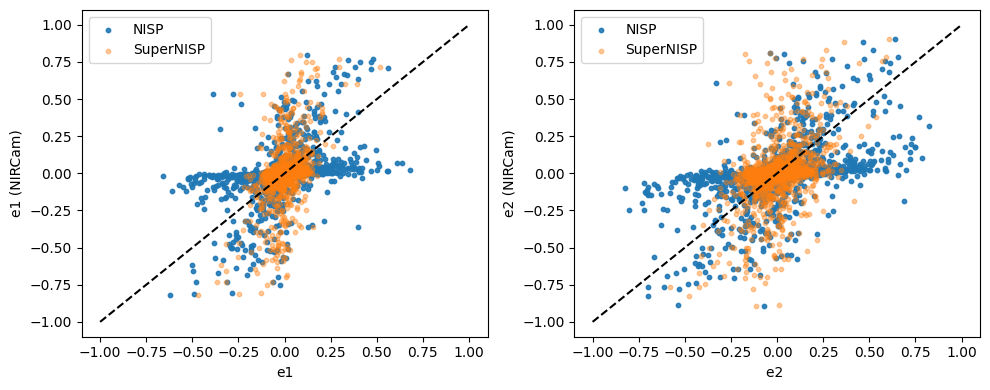

In [52]:
# Plot e1 and e2 comparisons
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].scatter(e1_lr, e1_hr, s=10, alpha=0.9, label='NISP')
axs[0].scatter(e1_sr, e1_hr, s=10, alpha=0.4, label='SuperNISP')
axs[0].plot([-1, 1], [-1, 1], 'k--')
axs[0].set_xlabel("e1")
axs[0].set_ylabel("e1 (NIRCam)")
axs[0].legend()

axs[1].scatter(e2_lr, e2_hr, s=10, alpha=0.9, label='NISP')
axs[1].scatter(e2_sr, e2_hr, s=10, alpha=0.4, label='SuperNISP')
axs[1].plot([-1, 1], [-1, 1], 'k--')
axs[1].set_xlabel("e2 ")
axs[1].set_ylabel("e2 (NIRCam)")
axs[1].legend()

plt.tight_layout()
plt.show()


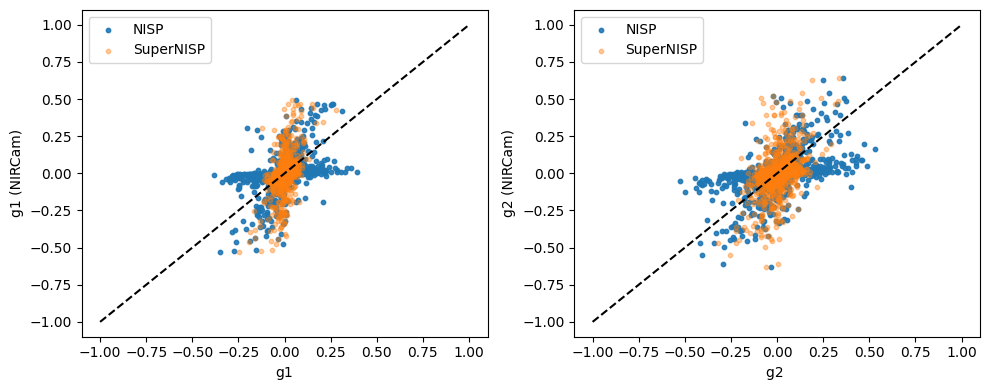

In [53]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].scatter(g1_lr, g1_hr, s=10, alpha=0.9, label='NISP')
axs[0].scatter(g1_sr, g1_hr, s=10, alpha=0.4, label='SuperNISP')
axs[0].plot([-1, 1], [-1, 1], 'k--')
axs[0].set_xlabel("g1")
axs[0].set_ylabel("g1 (NIRCam)")
axs[0].legend()

axs[1].scatter(g2_lr, g2_hr, s=10, alpha=0.9, label='NISP')
axs[1].scatter(g2_sr, g2_hr, s=10, alpha=0.4, label='SuperNISP')
axs[1].plot([-1, 1], [-1, 1], 'k--')
axs[1].set_xlabel("g2 ")
axs[1].set_ylabel("g2 (NIRCam)")
axs[1].legend()

plt.tight_layout()
plt.show()


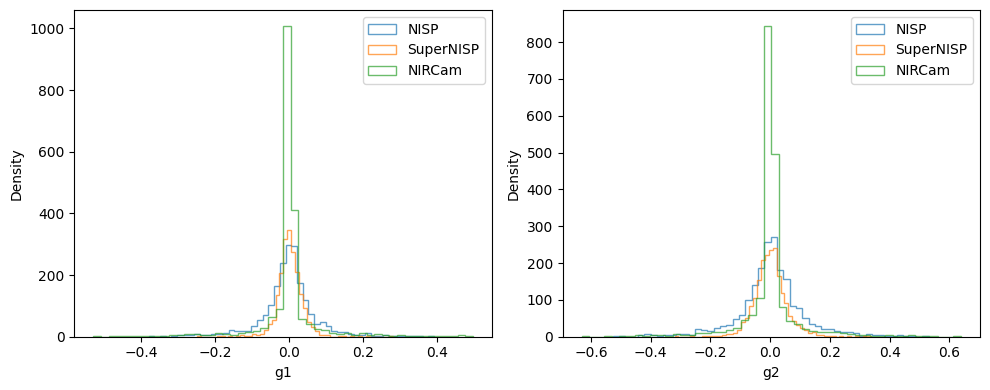

In [54]:

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Histogram for g1
axs[0].hist(g1_lr, bins=50, alpha=0.7, label='NISP',histtype='step')
axs[0].hist(g1_sr, bins=50, alpha=0.7, label='SuperNISP',histtype='step')
axs[0].hist(g1_hr, bins=50, alpha=0.7, label='NIRCam',histtype='step')
axs[0].set_xlabel("g1")
axs[0].set_ylabel("Density")
axs[0].legend()

# Histogram for g2
axs[1].hist(g2_lr, bins=50, alpha=0.7, label='NISP',histtype='step')
axs[1].hist(g2_sr, bins=50, alpha=0.7, label='SuperNISP',histtype='step')
axs[1].hist(g2_hr, bins=50, alpha=0.7, label='NIRCam',histtype='step')
axs[1].set_xlabel("g2")
axs[1].set_ylabel("Density")
axs[1].legend()

plt.tight_layout()
plt.show()


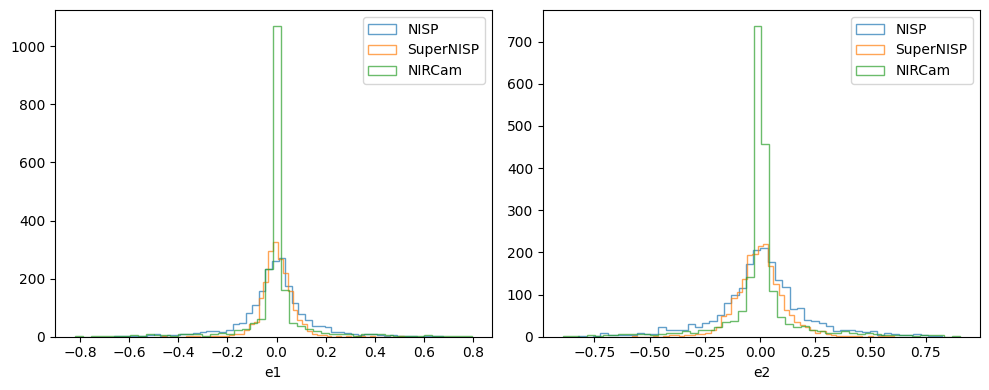

In [55]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Histogram for g1
axs[0].hist(e1_lr, bins=50, alpha=0.7, label='NISP',histtype='step')
axs[0].hist(e1_sr, bins=50, alpha=0.7, label='SuperNISP',histtype='step')
axs[0].hist(e1_hr, bins=50, alpha=0.7, label='NIRCam',histtype='step')
axs[0].set_xlabel("e1")
axs[0].legend()

# Histogram for g2
axs[1].hist(e2_lr, bins=50, alpha=0.7, label='NISP',histtype='step')
axs[1].hist(e2_sr, bins=50, alpha=0.7, label='SuperNISP',histtype='step')
axs[1].hist(e2_hr, bins=50, alpha=0.7, label='NIRCam',histtype='step')
axs[1].set_xlabel("e2")
axs[1].legend()

plt.tight_layout()
plt.show()
